In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reading the AmesHousing database


---


ابتدا باید فایل دیتابیس که از سایت کگل دانلود کرده ایم را به کمک کتابخانه پانداس بخوانیم و این دیتابیس را در یک متغیر ذخیره کنیم.

In [3]:
df = pd.read_csv('/content/AmesHousing(1).csv')

print("Dataset dimensions :")
print(f"Rows = {df.shape[0]} and Columns = {df.shape[1]}")
print('\n\n\n')
print(df)

Dataset dimensions :
Rows = 2930 and Columns = 82




      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9

# Preliminary Review


---


میخواهیم یک بررسی اولیه انجام دهیم تا ساختار کلی دیتابیس را متوجه شوبم.

برای اینکار اول از دستور head استفاده کردیم که ۵ سطر ابتدایی را به ما نشان میدهد البته میتوان داخل پرانتز ان تعداد سطری که میخواهیم به نمایش دربیاید را نیز بنویسیم.

دستور بعدی info است که اطلاعاتی مثل دیتاتایپ ستون ها را به ما میدهد.

همچنین دستور describe اطلاعاتی راجع به مقدار های ستون ها به ما میدهد مثلا تعداد و میانگین و انحراف معیار و کمترین و بیشترین داده ها در هر ستون.

همچنین برای اینکه بفهمیم چند داده گمشده داریم باید به دستور info نکاه کنیم که در ستون Non-Null Count تعداد داده های پر شده نوشته شده است.

In [45]:
print("---The first five rows of the dataset---\n".center(120))
df.index = range(1, len(df) + 1)
display(df.head())

print('\n\n\n')
print("---Column information and data types---\n")
df.info()

print('\n\n\n')
print("---Descriptive statistics of the variables---".center(120))
display(df.describe())

missing_counts = df.isnull().sum()
print('\n\n\n')
print("---count of missing data in each column---\n".center(120))
print(missing_counts)

                                       ---The first five rows of the dataset---
                                        


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,TotalSF,HouseAge
1,1,526301100,20,RL,141.0,31770,Pave,Grvl,IR1,Lvl,...,MnPrv,Shed,0,5,2010,WD,Normal,215000,2736.0,50
2,2,526350040,20,RH,80.0,11622,Pave,Grvl,Reg,Lvl,...,MnPrv,Shed,0,6,2010,WD,Normal,105000,1778.0,49
3,3,526351010,20,RL,81.0,14267,Pave,Grvl,IR1,Lvl,...,MnPrv,Gar2,12500,6,2010,WD,Normal,172000,2658.0,52
4,4,526353030,20,RL,93.0,11160,Pave,Grvl,Reg,Lvl,...,MnPrv,Shed,0,4,2010,WD,Normal,244000,4220.0,42
5,5,527105010,60,RL,74.0,13830,Pave,Grvl,IR1,Lvl,...,MnPrv,Shed,0,3,2010,WD,Normal,189900,2557.0,13






---Column information and data types---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 1 to 2930
Data columns (total 84 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            2930 non-null   object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type      

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,TotalSF,HouseAge
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.019795,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.096928,...,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,2551.283959,36.434130
std,845.96247,1.887308e+08,42.638025,21.326422,7880.017759,1.411026,1.111537,30.245361,20.860286,178.634545,...,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,804.766151,30.291357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,334.000000,-1.000000
25%,733.25000,5.284770e+08,20.000000,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,2004.000000,7.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,2452.000000,34.000000
75%,2197.75000,9.071811e+08,70.000000,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,2994.500000,54.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,11752.000000,136.000000






                                      ---count of missing data in each column---
                                       
Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Sale Type         0
Sale Condition    0
SalePrice         0
TotalSF           0
HouseAge          0
Length: 84, dtype: int64


# Histogram
دراینجا نمودار هیستوگرام برای داده های اولیه را رسم کردم سپس مدل لوگاریتمی ان را رسم کردم که داده ها بیشتر در وسط متمرکز بودند به خاطر همین چولگی نمودار کمتر بود و در نتیحه تقریبا نمودار نرمال بود.
> **همچنین تابع چگالی احتمال توزیع نرمال از رابطه زیر بدست میاید :**





# ***$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$***

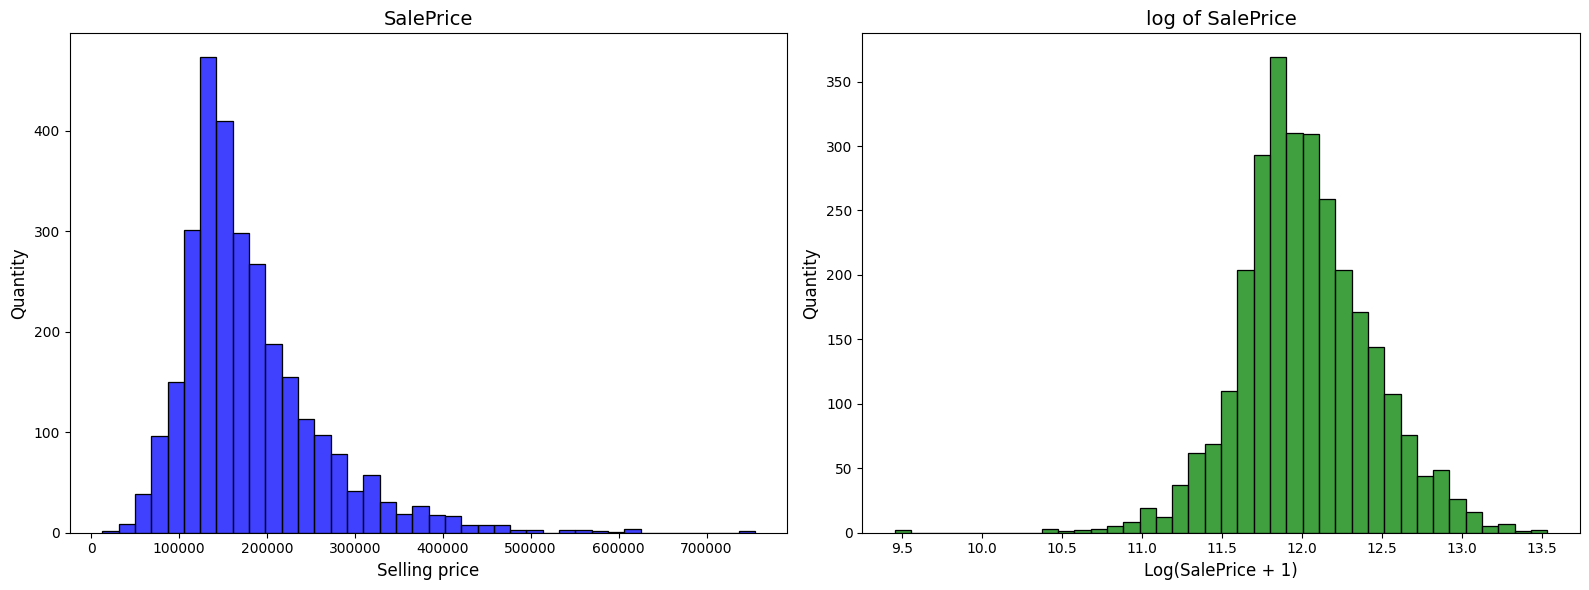

Skewness of the initial histogram : 1.74
Skewness of the logarithmic histogram : -0.01
The initial histogram is unnormal.
The logarithmic histogram is normal.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['SalePrice'], color='blue', ax=axes[0], bins=40)
axes[0].set_title('SalePrice', fontsize=14)
axes[0].set_xlabel('Selling price', fontsize=12)
axes[0].set_ylabel('Quantity', fontsize=12)

sns.histplot(np.log1p(df['SalePrice']), color='green', ax=axes[1], bins=40)
axes[1].set_title('log of SalePrice', fontsize=14)
axes[1].set_xlabel('Log(SalePrice + 1)', fontsize=12)
axes[1].set_ylabel('Quantity', fontsize=12)

plt.tight_layout()
plt.show()
initial_skewness = df['SalePrice'].skew()
log_skewness = np.log1p(df['SalePrice']).skew()
print(f"Skewness of the initial histogram : {initial_skewness:.2f}")
print(f"Skewness of the logarithmic histogram : {log_skewness:.2f}")
if (initial_skewness < 0.5 and initial_skewness > -0.5) :
  print("The initial histogram is normal.")
else :
  print("The initial histogram is unnormal.")
if (log_skewness < 0.5 and log_skewness > -0.5) :
  print("The logarithmic histogram is normal.")
else :
  print("The logarithmic histogram is unnormal.")

# Missing data management


In [6]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()

for i in numerical:
    if df[i].isnull().sum() == df.shape[0]:
        df[i].fillna(0, inplace=True)
    elif df[i].isnull().sum() > 0:
        mean = df[i].median()
        df[i].fillna(mean, inplace=True)

for i in categorical:
    if df[i].isnull().sum() == df.shape[0]:
        df[i].fillna("None", inplace=True)
    elif df[i].isnull().sum() > 0:
        mod = df[i].mode()[0]
        df[i].fillna(mod, inplace=True)
print(df)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL          68.0      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Alley Lot Shape Land Contour  ... 

/tmp/ipykernel_7227/2036663552.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(mean, inplace=True)
/tmp/ipykernel_7227/2036663552.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

# Categorical Data Encoding

In [44]:
encoded_cols = pd.get_dummies(df[['Neighborhood', 'House Style']], drop_first=True, dtype=int)
print(f"Number of new features generated by one-hot encoding : {encoded_cols.shape[1]}")
print('\n\n\n')
encoded_cols.index = range(1, len(encoded_cols) + 1)
encoded_cols.head()

Number of new features generated by one-hot encoding : 34






,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


# Create a new feature

In [43]:
df['TotalSF'] = df['Gr Liv Area'] + df['Total Bsmt SF']

df['HouseAge'] = df['Yr Sold'] - df['Year Built']



print("---Add Total SF feature---\n\n\n".center(52))
df_display_1 = df[['Gr Liv Area', 'Total Bsmt SF', 'TotalSF', 'SalePrice']]
df_display_1.index = range(1, len(df_display_1) + 1)
display(df_display_1.head())

print('\n\n\n')

print("---Add HouseAge feature---\n\n\n".center(35))
df_display = df[['Yr Sold', 'Year Built', 'HouseAge']]
df_display.index = range(1, len(df_display) + 1)
display(df_display.head())

           ---Add Total SF feature---


            


,Gr Liv Area,Total Bsmt SF,TotalSF,SalePrice
1,1656,1080.0,2736.0,215000
2,896,882.0,1778.0,105000
3,1329,1329.0,2658.0,172000
4,2110,2110.0,4220.0,244000
5,1629,928.0,2557.0,189900






   ---Add HouseAge feature---


   


,Yr Sold,Year Built,HouseAge
1,2010,1960,50
2,2010,1961,49
3,2010,1958,52
4,2010,1968,42
5,2010,1997,13


# Key Feature Selection

In [38]:
Feature = df[['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'TotalSF']]

print("---Some features in a table---\n\n\n".center(64))
Feature.index = range(1, len(Feature) + 1)
display(Feature.head())

               ---Some features in a table---


                


,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built,TotalSF
1,6,1656,1080.0,1960,2736.0
2,5,896,882.0,1961,1778.0
3,6,1329,1329.0,1958,2658.0
4,7,2110,2110.0,1968,4220.0
5,5,1629,928.0,1997,2557.0


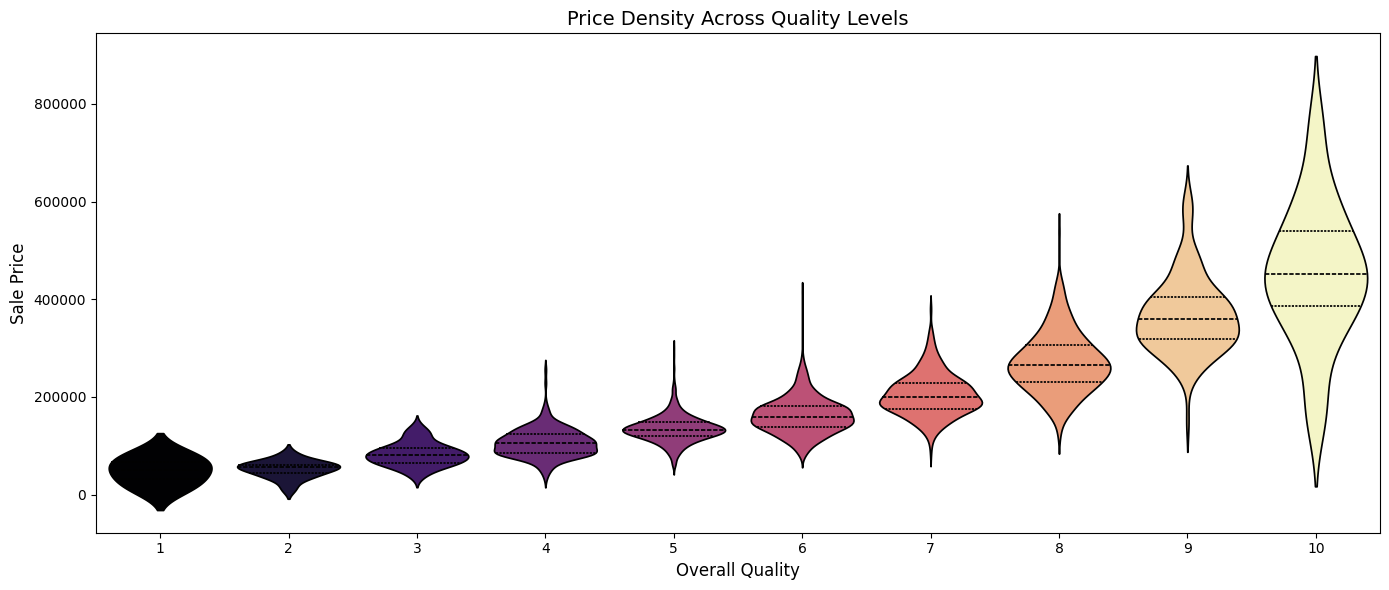

In [10]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='Overall Qual', y='SalePrice', palette='magma', inner='quartile', hue='Overall Qual', legend=False)

plt.title('Price Density Across Quality Levels', fontsize=14)
plt.xlabel('Overall Quality', fontsize=12)
plt.ylabel('Sale Price', fontsize=12)
plt.tight_layout()
plt.show()

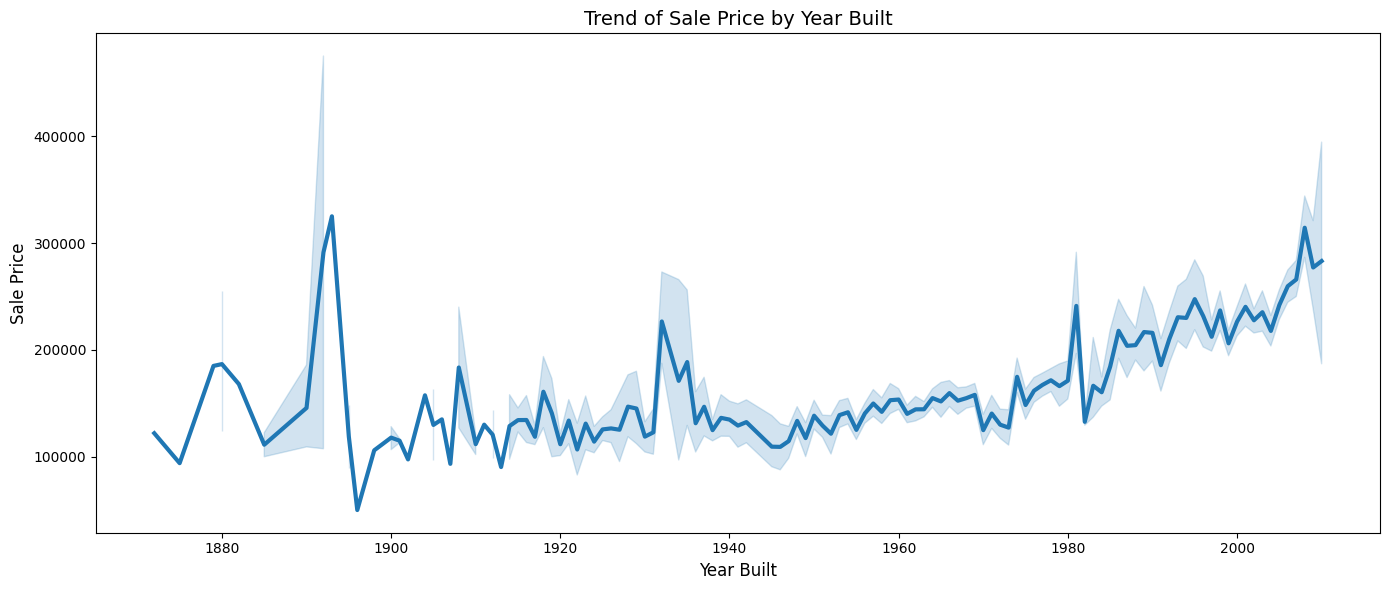

In [11]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Year Built', y='SalePrice', linewidth=3)

plt.title('Trend of Sale Price by Year Built', fontsize=14)
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Sale Price', fontsize=12)
plt.tight_layout()
plt.show()

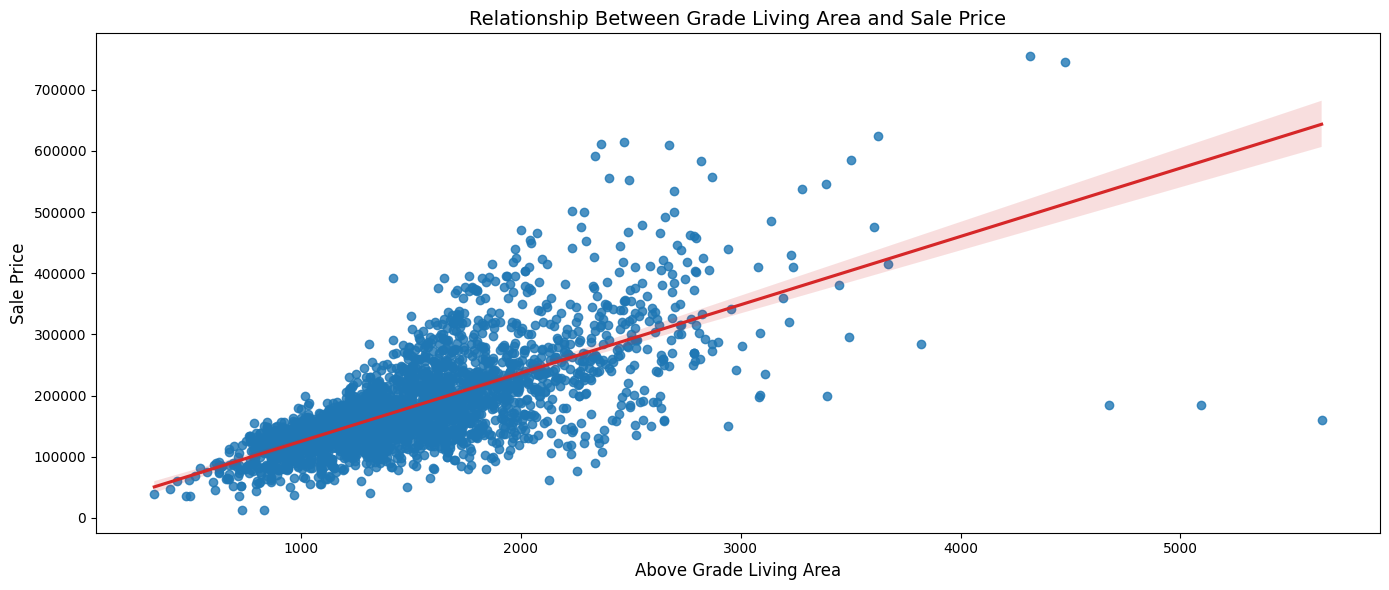

In [12]:
plt.figure(figsize=(14, 6))
sns.regplot(data=df, x='Gr Liv Area', y='SalePrice', line_kws={'color': '#d62728'})

plt.title('Relationship Between Grade Living Area and Sale Price', fontsize=14)
plt.xlabel('Above Grade Living Area', fontsize=12)
plt.ylabel('Sale Price', fontsize=12)
plt.tight_layout()
plt.show()

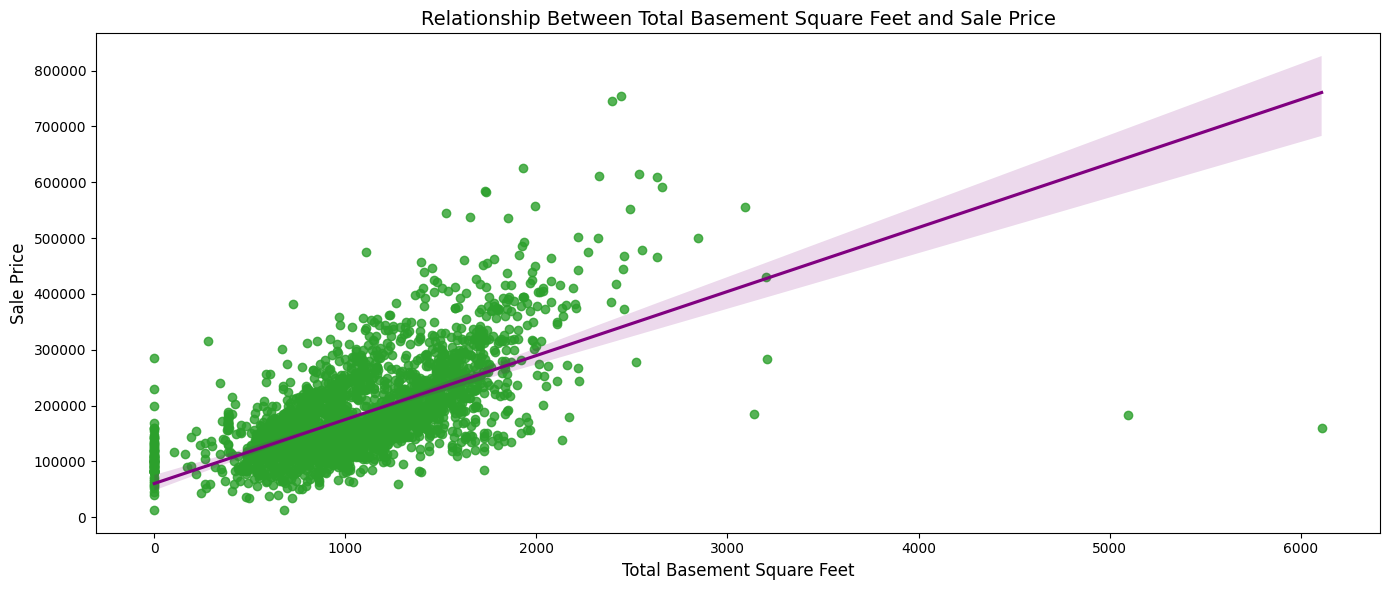

In [13]:
plt.figure(figsize=(14, 6))
sns.regplot(data=df, x='Total Bsmt SF', y='SalePrice', scatter_kws={'color': '#2ca02c'}, line_kws={'color': '#800080'})

plt.title('Relationship Between Total Basement Square Feet and Sale Price', fontsize=14)
plt.xlabel('Total Basement Square Feet', fontsize=12)
plt.ylabel('Sale Price', fontsize=12)
plt.tight_layout()
plt.show()

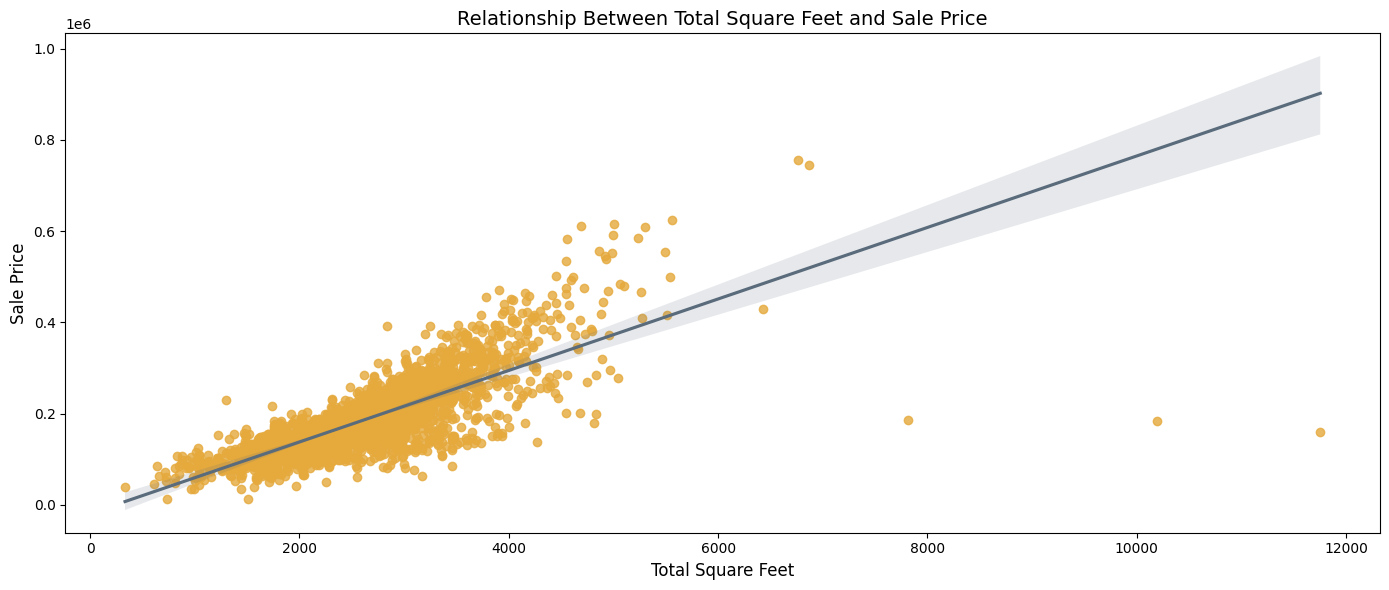

In [14]:
plt.figure(figsize=(14, 6))
sns.regplot(data=df, x='TotalSF', y='SalePrice', scatter_kws={'color': '#E5A93C'}, line_kws={'color': '#5A6B7C'})

plt.title('Relationship Between Total Square Feet and Sale Price', fontsize=14)
plt.xlabel('Total Square Feet', fontsize=12)
plt.ylabel('Sale Price', fontsize=12)
plt.tight_layout()
plt.show()

# Scatter Plot

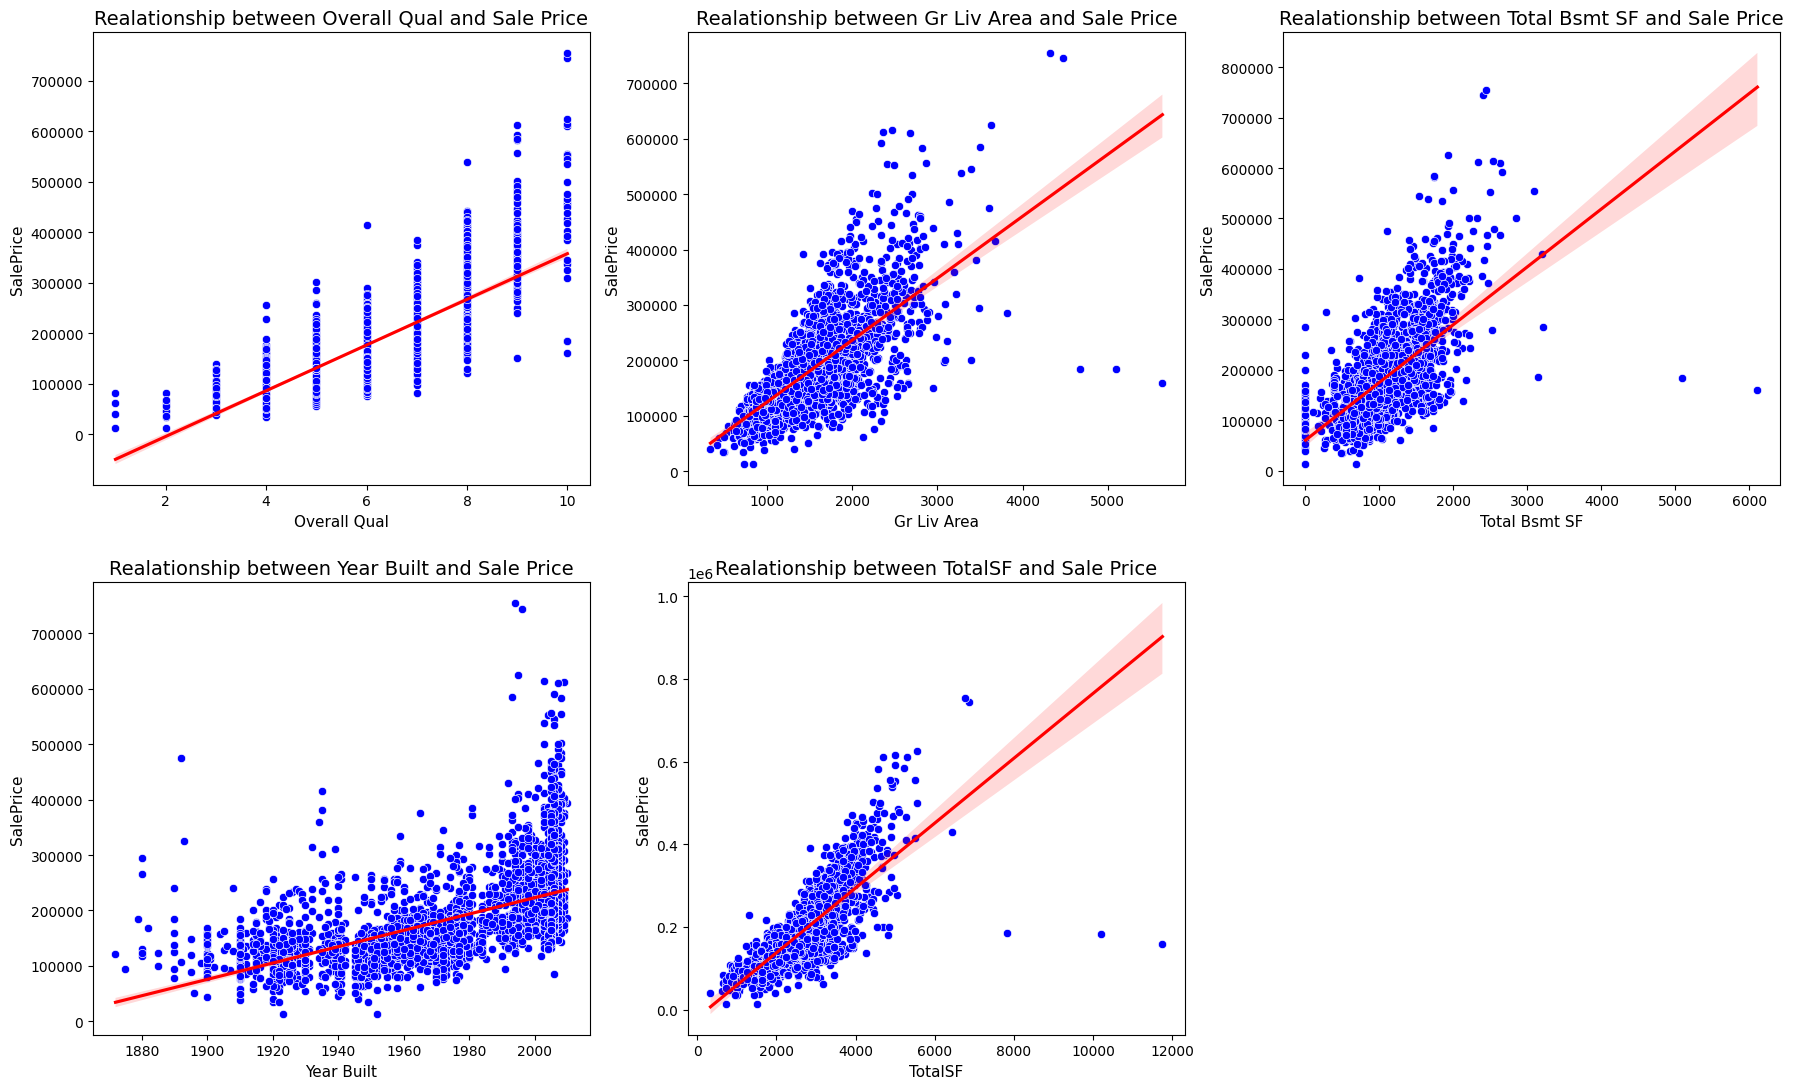

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, feature in enumerate(Feature):
    sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[i], color='blue')
    sns.regplot(data=df, x=feature, y='SalePrice', ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'Realationship between {feature} and Sale Price', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('SalePrice', fontsize=11)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# Data Sepration


In [31]:
# تفکیک داده‌ها به ۸۰٪ آموزش و ۲۰٪ آزمون
X_train, X_test, y_train, y_test = train_test_split(Feature, df['SalePrice'], test_size=0.20, random_state=42)

print(f"تعداد داده‌های آموزش: {X_train.shape[0]}")
print(f"تعداد داده‌های آزمون: {X_test.shape[0]}")

      Overall Qual  Gr Liv Area  Total Bsmt SF  Year Built  TotalSF
381              7         1370         1090.0        1976   2460.0
834              5         2126         1013.0        1967   3139.0
1898             4         1224            0.0        1962   1224.0
678              4         1040            0.0        1949   1040.0
700              4         1701          600.0        1920   2301.0
...            ...          ...            ...         ...      ...
1638             5         1424         1100.0        1969   2524.0
1095             7         1414          707.0        2002   2121.0
1130             6         1728          864.0        2003   2592.0
1294             5         1740          936.0        1920   2676.0
860              5          768          768.0        1972   1536.0

[2344 rows x 5 columns]
تعداد داده‌های آموزش: 2344
تعداد داده‌های آزمون: 586


# Model Definition and Selection

In [ ]:
model = LinearRegression()

# Model Training

In [48]:
model.fit(X_train, y_train)

LinearRegression()

In [46]:
coef = pd.DataFrame({
    'Feature': Feature.columns.tolist(),
    'Coefficient': model.coef_
})
coef.index = range(1, len(coef) + 1)
print("---Linear regression model coefficients---\n\n\n")
display(coef.style.format({'Coefficient': '{:.2f}'}))

---Linear regression model coefficients---





,Feature,Coefficient
1,Overall Qual,22408.89
2,Gr Liv Area,26.43
3,Total Bsmt SF,2.26
4,Year Built,432.71
5,TotalSF,28.69


# Model Evaluation

In [66]:
y_pred= model.predict(X_test)

RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
MAE= mean_absolute_error(y_test, y_pred)
acc = r2_score(y_test, y_pred)

print("---Linear regression model evaluation results on the test set---\n\n\n")

print(f"Root Mean Squared Error : ${RMSE:,.2f}\n")
print(f"Mean Absolute Error : ${MAE:,.2f}\n")
print(f"R-squared Score (R2) : {acc*100:.2f}%")

---Linear regression model evaluation results on the test set---



Root Mean Squared Error : $40,988.26

Mean Absolute Error : $26,376.09

Model accuracy : 79.05%


# Interpretation of Results

In [95]:
mean_actual_price = y_test.mean()
MAE_percent = (mae / mean_actual_price) * 100

BOLD = '\033[1m'
UNDERLINE = '\033[4m'
RESET = '\033[0m'

title = f"{BOLD}{UNDERLINE}LINEAR REGRESSION PERFORMANCE REPORT{RESET}"
print(title.center(70))
print("\n\n\n")

print(f"Mean Actual House Price: ${mean_actual_price:,.2f}")
print(f"Mean Absolute Error (MAE): ${MAE:,.2f} ({MAE_percent:.2f}% of mean price)")
print(f"Root Mean Squared Error (RMSE): ${RMSE:,.2f}")
print(f"Model accuracy : {r2:.2f}")
print(f"Model eror : {MAE_percent:.2f}%\n\n\n")

if RMSE > MAE:
    ratio = RMSE / MAE
    print(f"\nتحلیل اثر نقاط پرت (RMSE vs MAE):")
    print(f"مقدار RMSE حدود {ratio:.2f} برابر MAE است.")
    print("این اختلاف ناشی از حساسیت بالاتر توان دوم در RMSE به خطاهای بزرگ است")
    print("و نشان می‌دهد مدل برای املاک با متراژ بسیار بالا یا خانه‌های لوکس خطاهای بزرگ‌تری دارد.\n\n\n\n")

Eror_Percent = (np.abs(y_test - y_pred) / y_test ) * 100
error_analysis = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred, 'Absolute Error': np.abs(y_test - y_pred), 'Eror Percent': Eror_Percent}, index=y_test.index)

top_errors = error_analysis.sort_values(by='Eror Percent', ascending=False).head(10)
top_errors.index = range(1, len(top_errors) + 1)

print("---Top 10 Higher eror---\n".center(65))
display(top_errors.style.format({'Actual Price': '${:,.2f}','Predicted Price': '${:,.2f}','Absolute Error': '${:,.2f}','Eror Percent': '{:,.2f}%'}))

           LINEAR REGRESSION PERFORMANCE REPORT           




Mean Actual House Price: $189,651.47
Mean Absolute Error (MAE): $26,376.09 (13.91% of mean price)
Root Mean Squared Error (RMSE): $40,988.26
Model accuracy : 0.79
Model eror : 13.91%




تحلیل اثر نقاط پرت (RMSE vs MAE):
مقدار RMSE حدود 1.55 برابر MAE است.
این اختلاف ناشی از حساسیت بالاتر توان دوم در RMSE به خطاهای بزرگ است
و نشان می‌دهد مدل برای املاک با متراژ بسیار بالا یا خانه‌های لوکس خطاهای بزرگ‌تری دارد.




                    ---Top 10 Higher eror---
                    


,Actual Price,Predicted Price,Absolute Error,Eror Percent
1,"$184,750.00","$522,744.62","$337,994.62",182.95%
2,"$60,000.00","$144,452.90","$84,452.90",140.75%
3,"$60,000.00","$-15,927.68","$75,927.68",126.55%
4,"$50,000.00","$97,107.47","$47,107.47",94.21%
5,"$59,000.00","$5,501.04","$53,498.96",90.68%
6,"$60,000.00","$10,144.48","$49,855.52",83.09%
7,"$61,500.00","$16,143.00","$45,357.00",73.75%
8,"$130,000.00","$223,701.38","$93,701.38",72.08%
9,"$130,000.00","$223,570.78","$93,570.78",71.98%
10,"$66,500.00","$110,532.34","$44,032.34",66.21%
